In [106]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

In [117]:
def tbillrate():
    df = pd.read_csv("data/TB3MS.csv")
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df["TB3MS"] /= 100
    return df.set_index("observation_date")
def compute_gold_tr(df):
    for colname in df.columns:
        df[colname+'TR'] = df[colname]/df[colname].shift(1)
    return df
def goldprice():
    col = {"CRUDE_DUBAI":"crude", "GOLD":"gold", "SILVER":"silver"}
    df = pd.read_csv("data/cmo-data-monthly.csv")[["date"]+list(col.keys())]
    df["date"] = pd.to_datetime(df["date"])+dt.timedelta(days=1)
    df = df.loc[df["date"]>=dt.datetime(1971,2,1)]
    return compute_gold_tr(df.set_index("date").rename(columns=col))
def read_shiller_out():
    df = pd.read_csv("data/shiller_out.csv")
    df['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d")+dt.timedelta(days=-14)
    df = df.set_index("Date")
    for c in df.columns:
        df[c] = df[c].astype(float)
    df['Rate10y'] = df['Rate10y']/100
    return df.join(tbillrate()).join(goldprice(),how="inner")

"""
def compute_bond_tr(df):
    r = df['Rate10y']
    T = 10
    duration = -(1-np.exp(-r*T))/r
    bondcarry = r.shift(1)/12
    bondtotalret = 1+(r-r.shift(1))*duration+bondcarry
    df["bondTR"] = bondtotalret
def compute_eq_tr(df):
    df['eqTR'] = df['SP500']/df['SP500'].shift(1)+df['Div']/12/df['SP500']
def compute_cpi_tr(df):
    df['cpiTR'] = 1+df['CPI'].pct_change()
    """
def compute_tbill_tr(df):
    df['tbTR'] = 1+df['TB3MS'].shift(1)*365/360/12

    
df = read_shiller_out()
#compute_gold_tr(df)
compute_tbill_tr(df)
# df.to_csv("totalreturns.csv")
df.columns

Index(['SP500', 'Div', 'Earning', 'CPI', 'Rate10y', 'cpiTR', 'eqTR', 'bondTR',
       'TB3MS', 'crude', 'gold', 'silver', 'crudeTR', 'goldTR', 'silverTR',
       'tbTR'],
      dtype='object')

In [118]:
def metrics_monthly_ret(df):
    trcolumns = [c for c in df.columns if "TR"==c[-2:] and c!="cpiTR"]
    logret = np.log(df[trcolumns].dropna())
    mu,sigma = logret.mean()*12,logret.std()*np.sqrt(12)
    sigma["tbTR"] = 0
    mu += 0.5*sigma**2
    mustar = mu-mu["tbTR"]
    riskycol = trcolumns[:-1]
    data = {'mustar':mustar[riskycol],'sigma':sigma[riskycol]}
    data['sharpe'] = data['mustar']/data['sigma']
    corr = logret[riskycol].corr()
    for c in riskycol:
        data[f'rho({c[:-2]})'] = corr[c]
    return pd.DataFrame(data,index=riskycol)

dfmetrics = metrics_monthly_ret(df)
dfmetrics

,mustar,sigma,sharpe,rho(eq),rho(bond),rho(crude),rho(gold),rho(silver)
eqTR,0.067089,0.126193,0.531640,1.000000,0.051785,-0.039694,-0.026417,0.044678
bondTR,0.018752,0.070090,0.267543,0.051785,1.000000,-0.134534,-0.115774,-0.192321
crudeTR,0.082213,0.343585,0.239279,-0.039694,-0.134534,1.000000,0.167567,0.185553
goldTR,0.057663,0.164181,0.351219,-0.026417,-0.115774,0.167567,1.000000,0.715034
silverTR,0.064359,0.275233,0.233835,0.044678,-0.192321,0.185553,0.715034,1.000000


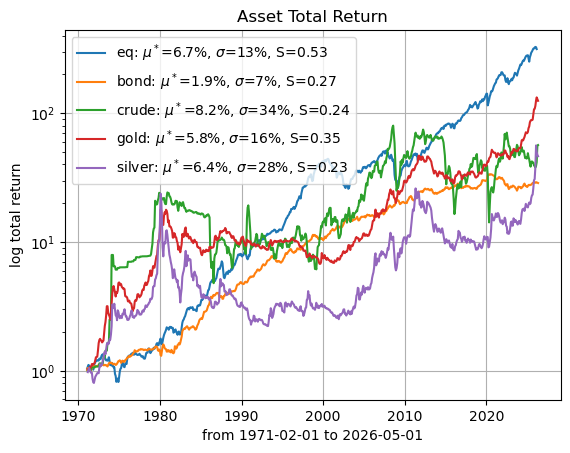

In [119]:
for c in dfmetrics.index:
    plt.plot(np.cumprod(df[c]),
             label=f"{c[:-2]}: $\mu^*$={dfmetrics.loc[c,'mustar']:.1%}, $\sigma$={dfmetrics.loc[c,'sigma']:.0%}, S={dfmetrics.loc[c,'sharpe']:.2f}")
plt.legend()
plt.title("Asset Total Return")
plt.ylabel("log total return")
plt.yscale('log')  
plt.xlabel(f"from {str(df.index[0])[:10]} to {str(df.index[-1])[:10]}")  
plt.grid(True)  
plt.show()


In [56]:
dfc = pd.read_csv("data/cmo-data-monthly.csv")
dfc["date"] = pd.to_datetime(dfc["date"])+dt.timedelta(days=1)
dfc = dfc.set_index("date")
dfc.columns

Index(['CRUDE_PETRO', 'CRUDE_BRENT', 'CRUDE_DUBAI', 'CRUDE_WTI', 'COAL_AUS',
       'COAL_SAFRICA', 'NGAS_US', 'NGAS_EUR', 'NGAS_JP', 'iNATGAS', 'COCOA',
       'COFFEE_ARABIC', 'COFFEE_ROBUS', 'TEA_AVG', 'TEA_COLOMBO',
       'TEA_KOLKATA', 'TEA_MOMBASA', 'COCONUT_OIL', 'GRNUT', 'FISH_MEAL',
       'GRNUT_OIL', 'PALM_OIL', 'PLMKRNL_OIL', 'SOYBEANS', 'SOYBEAN_OIL',
       'SOYBEAN_MEAL', 'RAPESEED_OIL', 'SUNFLOWER_OIL', 'BARLEY', 'MAIZE',
       'SORGHUM', 'RICE_05', 'RICE_25', 'RICE_A1', 'RICE_05_VNM',
       'WHEAT_US_SRW', 'WHEAT_US_HRW', 'BANANA_EU', 'BANANA_US', 'ORANGE',
       'BEEF', 'CHICKEN', 'LAMB', 'SHRIMP_MEX', 'SUGAR_EU', 'SUGAR_US',
       'SUGAR_WLD', 'TOBAC_US', 'LOGS_CMR', 'LOGS_MYS', 'SAWNWD_CMR',
       'SAWNWD_MYS', 'PLYWOOD', 'COTTON_A_INDX', 'RUBBER_TSR20',
       'RUBBER1_MYSG', 'PHOSROCK', 'DAP', 'TSP', 'UREA_EE_BULK', 'POTASH',
       'ALUMINUM', 'IRON_ORE', 'COPPER', 'LEAD', 'Tin', 'NICKEL', 'Zinc',
       'GOLD', 'PLATINUM', 'SILVER'],
      dtype='object')

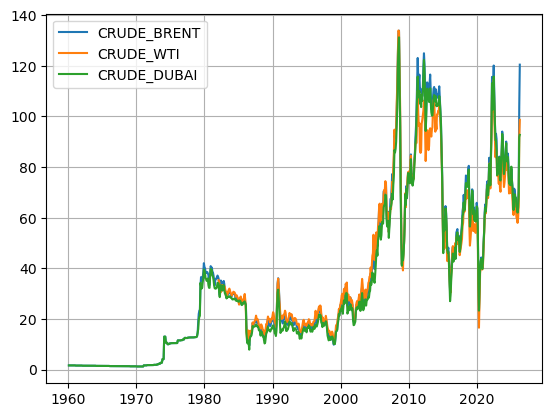

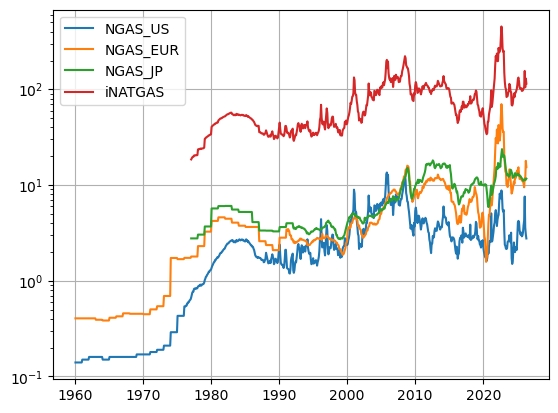

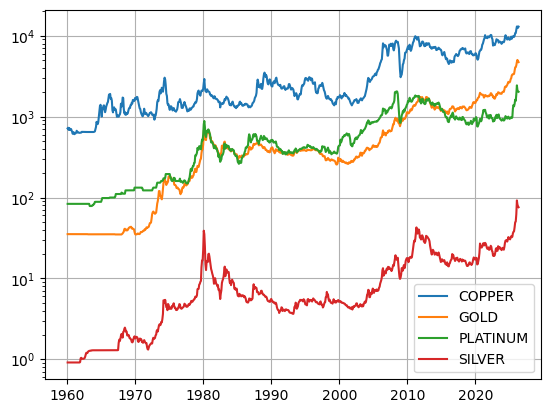

In [57]:
for c in ["CRUDE_BRENT","CRUDE_WTI","CRUDE_DUBAI"]:
    plt.plot(dfc[c], label=c)
plt.legend()
# plt.yscale('log')  
plt.grid(True)     
plt.show()

for c in ["NGAS_US","NGAS_EUR","NGAS_JP","iNATGAS"]:
    plt.plot(dfc[c], label=c)
plt.legend()
plt.yscale('log')  
plt.grid(True)     
plt.show()

for c in ["COPPER","GOLD","PLATINUM","SILVER"]:
    plt.plot(dfc[c], label=c)
plt.legend()
plt.yscale('log')  
plt.grid(True)     
plt.show()